# U13 — Optimization (Part 1): Lab

### Real-world brief: predicting building energy use — and watching a model *learn*

You'll predict a building's daily energy use (kWh) from its floor area. But instead of calling a library, you'll **code gradient descent yourself** to see exactly how a model finds its parameters — the engine under almost every ML algorithm.

**Resource provided:** `energy_consumption.csv` (one row per building). Keep it beside this notebook (upload it in Colab).

_Phase D — Model Training & Optimization._

#objectives

Define a loss function (MSE) and visualise the loss 'bowl'

Implement gradient descent from scratch and watch the loss fall

See how the learning rate controls speed — and can cause divergence

Demonstrate why feature scaling speeds up optimisation

Check your hand-coded result against scikit-learn

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [2]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_energy(csv_path="energy_consumption.csv", seed=5, verbose=False):
    """Clean regression dataset for coding gradient descent from scratch:
    predict a building's daily energy use (kWh).

    - 'floor_area_sqft' has a strong, mostly-linear relationship with energy
      (ideal for the single-feature loss-bowl demo).
    - 'occupancy' is on a very different scale from floor_area, so the two
      together make the feature-scaling-speeds-optimization demo land clearly.
    """
    rng = np.random.default_rng(seed)
    N = 600

    floor_area = np.clip(rng.normal(2200, 900, N), 300, 6000).round(0)   # ~100s-1000s
    occupancy = np.clip(rng.normal(25, 12, N), 1, 80).round(0)           # ~tens
    avg_temp_c = np.clip(rng.normal(24, 6, N), 8, 42).round(1)
    insulation = rng.integers(1, 6, N)                                   # 1 (poor) .. 5 (great)

    # daily energy (kWh): dominated by floor area, plus occupancy & cooling load
    energy = (1.05 * floor_area
              + 18.0 * occupancy
              + 35.0 * np.clip(avg_temp_c - 22, 0, None)   # cooling above 22C
              - 60.0 * insulation
              + rng.normal(0, 120, N))
    energy = np.clip(energy, 50, None).round(1)

    df = pd.DataFrame({
        "building_id": [f"BLD{i+1:04d}" for i in range(N)],
        "floor_area_sqft": floor_area.astype(int),
        "occupancy": occupancy.astype(int),
        "avg_temp_c": avg_temp_c,
        "insulation_score": insulation,
        "energy_kwh": energy,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("energy:", df.shape)
        print("corr(area, energy):", round(df["floor_area_sqft"].corr(df["energy_kwh"]), 3))
        print("energy range:", df["energy_kwh"].min(), "-", df["energy_kwh"].max())
    return df

if not os.path.exists('energy_consumption.csv'):
    build_energy(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('energy_consumption.csv')
print('shape:', df.shape)
df.head(3)

shape: (600, 6)


,building_id,floor_area_sqft,occupancy,avg_temp_c,insulation_score,energy_kwh
0,BLD0001,1478,49,28.0,4,2206.6
1,BLD0002,1008,16,8.0,1,1258.1
2,BLD0003,1976,27,21.4,1,2221.9


#1. The problem and the loss function

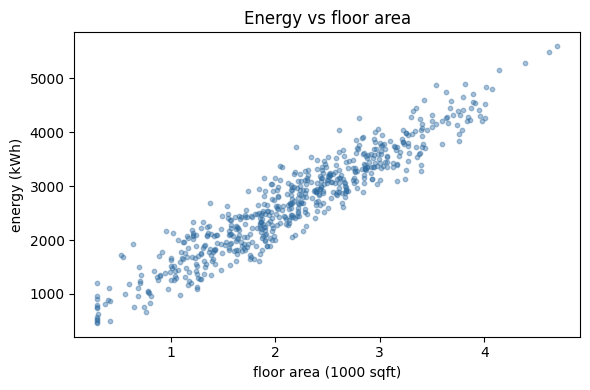

MSE at w=0, b=0: 8176582.4


In [4]:
# -----------------------------------------------------------
# 🔹 1A. ONE FEATURE: floor_area -> energy_kwh
# -----------------------------------------------------------
# Work in thousands of sqft so the numbers are friendly.
x = df['floor_area_sqft'].values / 1000.0      # feature
y = df['energy_kwh'].values                    # target

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.set_title('Energy vs floor area'); plt.tight_layout(); plt.show()

def mse(w, b):
    pred = w * x + b
    return np.mean((y - pred) ** 2)
print('MSE at w=0, b=0:', round(mse(0, 0), 1))

#2. The loss landscape (the 'bowl')

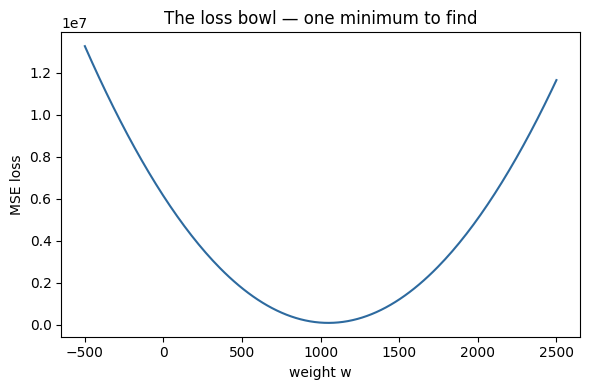

The curve is convex: a single lowest point gradient descent can reach.


In [5]:
# -----------------------------------------------------------
# 🔹 2A. SWEEP THE WEIGHT w (fix b) AND PLOT THE LOSS
# -----------------------------------------------------------
b_fixed = y.mean() - 1.05 * x.mean() * 1000   # a reasonable intercept
ws = np.linspace(-500, 2500, 200)
losses = [mse(w, b_fixed) for w in ws]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ws, losses, color='#2D6A9F')
ax.set_xlabel('weight w'); ax.set_ylabel('MSE loss')
ax.set_title('The loss bowl — one minimum to find')
plt.tight_layout(); plt.show()
print('The curve is convex: a single lowest point gradient descent can reach.')

#3. Gradient descent from scratch

In [6]:
# -----------------------------------------------------------
# 🔹 3A. THE GRADIENTS OF MSE, THEN THE UPDATE LOOP
# -----------------------------------------------------------
# MSE = mean((y - (w*x+b))^2)
#   dL/dw = -2 * mean(x * (y - pred))
#   dL/db = -2 * mean(    (y - pred))
def gradients(w, b):
    pred = w * x + b
    err = y - pred
    dw = -2 * np.mean(x * err)
    db = -2 * np.mean(err)
    return dw, db

def gradient_descent(lr=0.1, epochs=100):
    w, b = 0.0, 0.0
    history = []
    for _ in range(epochs):
        dw, db = gradients(w, b)
        w -= lr * dw          # the update rule:  theta <- theta - lr * grad
        b -= lr * db
        history.append(mse(w, b))
    return w, b, history

w, b, hist = gradient_descent(lr=0.1, epochs=100)
print(f'learned: w={w:.1f}, b={b:.1f}')
print(f'loss: {hist[0]:.0f} (start) -> {hist[-1]:.0f} (end)')

learned: w=1042.9, b=426.2
loss: 699089 (start) -> 94737 (end)


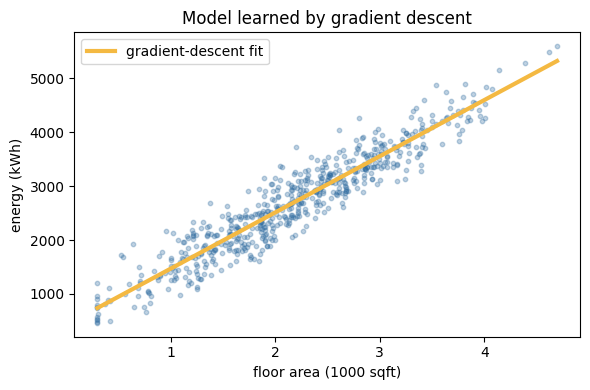

In [7]:
# Plot the fitted line over the data
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, w * xs + b, color='#F4B942', lw=3, label='gradient-descent fit')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.legend(); ax.set_title('Model learned by gradient descent')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 3 — Take one step by hand
1. Starting from `w=0, b=0`, call `gradients(0, 0)` and print `dw, db`.
2. Apply ONE update with learning rate 0.1 and print the new `w, b`.
3. Confirm the loss after one step is lower than `mse(0, 0)`.

In [18]:
# 1. gradients at the start
dw_init, db_init = gradients(0, 0)
print(dw_init)
print(db_init)

# 2. one manual update step (lr=0.1)
lr = 0.1
w_manual = 0.0 - lr * dw_init
b_manual = 0.0 - lr * db_init
print(lr,w,b)

# 3. show the loss dropped
initial_mse = mse(0, 0)
mse_after_one_step = mse(w_manual, b_manual)
print(initial_mse)
print(mse_after_one_step)
if mse_after_one_step < initial_mse:
    print('Loss has dropped after one step, as expected.')
else:
    print('Loss did NOT drop after one step. Something might be wrong.')

-13293.906055333331
-5395.344
0.1 1042.8970098058282 426.2038086708811
8176582.3501
699089.0822761774
Loss has dropped after one step, as expected.


#4. The loss curve over epochs

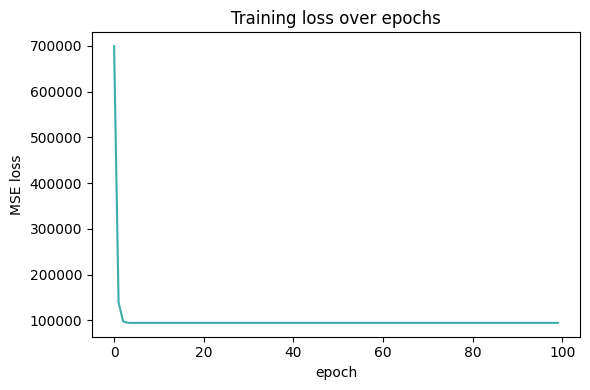

Steep early improvement, then a flat tail = converged.


In [9]:
# -----------------------------------------------------------
# 🔹 4A. LOSS SHOULD FALL FAST, THEN FLATTEN (convergence)
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist, color='#3AAFA9')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Training loss over epochs'); plt.tight_layout(); plt.show()
print('Steep early improvement, then a flat tail = converged.')

#5. The learning rate: too small, just right, too large

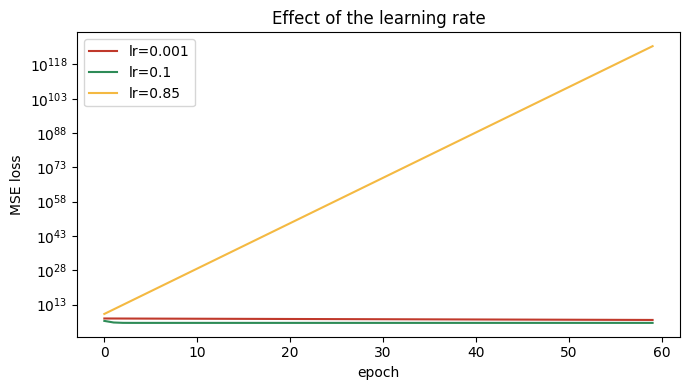

Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.


In [10]:
# -----------------------------------------------------------
# 🔹 5A. RUN GD AT THREE LEARNING RATES
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for lr, col in [(0.001, '#C0392B'), (0.1, '#2E8B57'), (0.85, '#F4B942')]:
    _, _, h = gradient_descent(lr=lr, epochs=60)
    ax.plot(h, label=f'lr={lr}', color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend()
ax.set_title('Effect of the learning rate'); ax.set_yscale('log')
plt.tight_layout(); plt.show()
print('Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.')

#### 🧪 EXERCISE 5 — Make it diverge
1. Run `gradient_descent` with a clearly-too-large learning rate (try `lr=1.5`, `epochs=30`).
2. Print the final loss — it should be **huge / inf / nan** (the steps overshoot and blow up).
3. In a comment, explain in one line why too large a learning rate diverges.

In [19]:
# 1. run with an overly large lr
_, _, divergent_history = gradient_descent(lr=1.5, epochs=30)

# 2. print the final loss (expect explosion)
final_divergent_loss = divergent_history[-1]
print(f'Final loss with lr=1.5: {final_divergent_loss:.2e}')

# 3. Why it diverges: If the learning rate is too large, the updates to the parameters (w and b) overshoot the minimum of the loss function, causing the loss to increase instead of decrease, leading to an explosion in error.

Final loss with lr=1.5: 2.35e+82


#6. Why feature scaling speeds up optimization

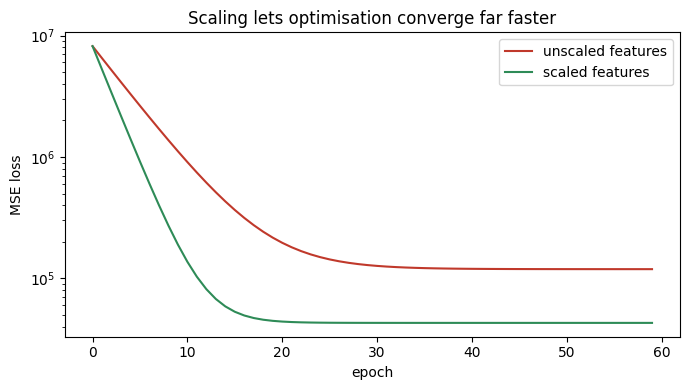

In [12]:
# -----------------------------------------------------------
# 🔹 6A. TWO FEATURES ON VERY DIFFERENT SCALES
# -----------------------------------------------------------
# floor_area (hundreds-thousands) and occupancy (tens) -> a stretched loss bowl.
X2 = df[['floor_area_sqft', 'occupancy']].values.astype(float)
yv = df['energy_kwh'].values

def gd_multi(Xm, lr=0.01, epochs=60):
    n, d = Xm.shape
    w = np.zeros(d); b = 0.0; hist = []
    for _ in range(epochs):
        pred = Xm @ w + b
        err = yv - pred
        w += lr * (2 / n) * (Xm.T @ err)
        b += lr * (2 / n) * err.sum()
        hist.append(np.mean(err ** 2))
    return hist

from sklearn.preprocessing import StandardScaler
X2s = StandardScaler().fit_transform(X2)
h_raw = gd_multi(X2, lr=1e-8, epochs=60)     # raw needs a tiny lr or it explodes
h_scaled = gd_multi(X2s, lr=0.1, epochs=60)  # scaled tolerates a healthy lr

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_raw, label='unscaled features', color='#C0392B')
ax.plot(h_scaled, label='scaled features', color='#2E8B57')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend(); ax.set_yscale('log')
ax.set_title('Scaling lets optimisation converge far faster')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 6 — Quantify the speed-up
1. Print the final loss of the unscaled run and the scaled run.
2. In a comment, explain why mismatched feature scales force a tiny learning rate (think about the shape of the loss bowl).

In [24]:
# 1. final losses
print(h_raw[-1])
print(h_scaled[-1])

# 2.  A tiny learning rate is needed to take small steps.

119137.67679420482
43004.7155202204


#7. Sanity-check against scikit-learn

In [14]:
# -----------------------------------------------------------
# 🔹 7A. DID OUR HAND-CODED GD FIND THE RIGHT ANSWER?
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression().fit(x.reshape(-1, 1), y)
print(f'gradient descent : w={w:.1f}, b={b:.1f}')
print(f'scikit-learn     : w={lr_model.coef_[0]:.1f}, b={lr_model.intercept_:.1f}')
print('They should be very close — our optimiser reached the same minimum.')

gradient descent : w=1042.9, b=426.2
scikit-learn     : w=1042.8, b=426.5
They should be very close — our optimiser reached the same minimum.


#### 🧪 EXERCISE 7 — Close the loop
1. Use the sklearn model to predict energy for a 3,000 sqft building (remember `x` is in thousands of sqft).
2. Do the same with your hand-coded `w, b` and confirm the two predictions match.

In [26]:
# 1. sklearn prediction for 3000 sqft
sqft_3000 = 3.0 # x is in thousands of sqft
prediction = lr_model.predict(np.array([[sqft_3000]]))
print(prediction)

# 2. your-GD prediction, and compare
gd_prediction = w * sqft_3000 + b
print(gd_prediction)

if np.isclose(prediction[0], gd_prediction, atol=1.0):
    print('match closely.')
else:
    print('do not match.')

[3554.83580415]
3554.894838088366
match closely.


#📘 Summary

| Step | What you saw |
| ---- | ------------ |
| Loss (MSE) | one number measuring how wrong the model is |
| Loss bowl | a convex curve with a single minimum |
| Gradient descent | step downhill: `w -= lr * dL/dw` |
| Loss curve | falls fast, then flattens at convergence |
| Learning rate | too small crawls, too large diverges |
| Scaling | rounds the bowl → far faster convergence |
| Check | hand-coded weights matched scikit-learn |

**You built the engine that trains nearly every ML model.** From linear regression to deep networks, it's this same loop — predict, measure loss, step down the gradient.

**Next — U13 Part 2:** momentum, Adam and adaptive learning rates, learning-rate schedules, and regularisation.